# Benchmarking Misc in Rust



This work focuses on converting code in tiatoolbox/models/engine/multi_task_segmentor.py from Python to Rust with the aim of reducing the time it takes to run the code. This Juypter notebook shows the speedup that certain functions are having being written in rust.



Rust is a programming language that is proven to be faster than Python, especially for CPU bound operations and processing large amounts of data.



This notebook compares the execution time of several function in two forms.
One the original python version
Two the modified function where some or all of the code has been moved to Rust



It tests how long it runs in Python and in Rust using different sized inputs. Each input size has multiple tests and the average of all the tests is taken to minimise the impact of any outliers. The x axis shows the size of the input and the y axis shows the average time taken of each input of size x.



This notebook will show which functions benefitted being moved into Rust.



# Part 1: Build Single QuPath Feature



### DaskDelayedJSONStore written fully in python



In [1]:
import numpy as np
from shapely.geometry import mapping
from shapely.geometry import shape as feature2geometry

from tiatoolbox.utils.misc import make_valid_poly


class PyDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def build_single_qupath_feature(
        self,
        i: int,
        class_dict: dict | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
        class_colors: dict,
    ) -> dict:
        """Build a single feature for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

            class_colors (dict):
                Maps classes to specific colors.

        Returns:
            dict:
                A fully constructed Feature dictionary instance for writing
                to QuPath JSON.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )
        geo_map = mapping(geom)

        props = {}
        class_value = None
        class_name = None

        for key, arr in self._processed_predictions.items():
            value = arr[i].tolist() if hasattr(arr[i], "tolist") else arr[i]

            if key == "type":
                # Handle None class name
                if value is None:
                    # Assign default class 0
                    class_value = 0
                    class_name = class_dict.get(0, 0)
                    props["type"] = class_name
                    continue

                # Safe class lookup
                if class_dict is not None and value in class_dict:
                    class_name = class_dict[value]
                else:
                    # Already a name or no mapping available
                    class_name = value

                props["type"] = class_name
                class_value = value
            else:
                if value is None:
                    continue
                props[key] = np.array(value).tolist()

        # Classification block
        if class_name is not None and class_value in class_colors:
            color = class_colors[class_value]
            props["classification"] = {
                "name": class_name,
                "color": color,
            }
            props["class_value"] = class_value

        return {
            "type": "Feature",
            "id": f"object_{i}",
            "geometry": geo_map,
            "properties": props,
            "objectType": "annotation",
            "name": class_name if class_name is not None else "object",
        }

### RustDaskDelayedJSONStore with some code written in rust



In [2]:
from tiatoolbox import rmultitask


class RustDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def build_single_qupath_feature(
        self,
        i: int,
        class_dict: dict | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
        class_colors: dict,
    ) -> dict:
        """Build a single feature for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

            class_colors (dict):
                Maps classes to specific colors.

        Returns:
            dict:
                A fully constructed Feature dictionary instance for writing
                to QuPath JSON.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )
        geo_map = mapping(geom)

        return rmultitask.build_single_qupath_feature(
            geo_map, self._processed_predictions, i, class_dict, class_colors
        )

## Comparison of speed it takes to run code in rust vs python



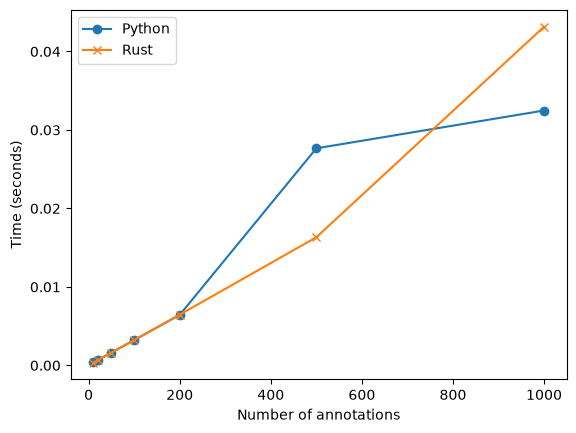

In [3]:
import time

import matplotlib.pyplot as plt
import numpy as np


def make_test_data(
    num_patches: int,
    num_classes: int,
    rng: np.random.Generator,
) -> tuple[
    np.ndarray,
    dict[str, np.ndarray],
    dict[int, str],
    dict[int, list[int]],
]:
    """Generate test data for build single qupath feature."""
    # Example square polygons.
    centres = rng.uniform(0, 10000, size=(num_patches, 2))

    square = np.array(
        [
            [-5.0, -5.0],
            [5.0, -5.0],
            [5.0, 5.0],
            [-5.0, 5.0],
            [-5.0, -5.0],
        ]
    )

    contours = np.array(
        [centre + square for centre in centres],
        dtype=object,
    )

    class_probs = rng.random((num_patches, num_classes))
    class_probs /= class_probs.sum(axis=1, keepdims=True)

    preds = np.argmax(class_probs, axis=1).astype(np.int32)

    processed_predictions = {
        "type": preds,
        "prob": np.max(class_probs, axis=1),
        "centroid": centres,
    }

    class_dict = {index: f"class_{index}" for index in range(num_classes)}

    cmap = plt.colormaps["tab20"].resampled(num_classes)

    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    return (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    )


rng = np.random.default_rng(42)

scale_factor = (0.5, 0.5)
origin = (0.0, 0.0)

sizes = []
timings = []

for num_patches in [10, 20, 50, 100, 200, 500, 1000]:
    num_classes = min(num_patches, 100)

    (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    ) = make_test_data(
        num_patches,
        num_classes,
        rng,
    )

    python_store = PyDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    rust_store = RustDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    python_times = []
    rust_times = []

    for _ in range(10):
        # Python
        start_time = time.time()

        python_objects = [
            python_store.build_single_qupath_feature(
                i,
                class_dict,
                origin,
                scale_factor,
                class_colours,
            )
            for i in range(num_patches)
        ]

        python_times.append(time.time() - start_time)

        start_time = time.time()

        rust_objects = [
            rust_store.build_single_qupath_feature(
                i,
                class_dict,
                origin,
                scale_factor,
                class_colours,
            )
            for i in range(num_patches)
        ]

        rust_times.append(time.time() - start_time)

    sizes.append(num_patches)

    timings.append(
        [
            np.mean(python_times),
            np.mean(rust_times),
        ]
    )

timings = np.asarray(timings)

plt.plot(sizes, timings[:, 0], label="Python", marker="o")
plt.plot(sizes, timings[:, 1], label="Rust", marker="x")
plt.xlabel("Number of annotations")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

# Part 2: Build Single Annotation



### DaskDelayedJSONStore written fully in python



In [4]:
import numpy as np

from tiatoolbox.annotation.storage import Annotation


class PyDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def build_single_annotation(
        self,
        i: int,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
    ) -> Annotation:
        """Build a single annotation for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

        Returns:
            Annotation:
                A fully constructed TIAToolbox `Annotation` instance.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )

        properties = {
            prop: (
                class_dict[self._processed_predictions[prop][i]]
                if prop == "type" and class_dict is not None
                else np.array(self._processed_predictions[prop][i]).tolist()
            )
            for prop in self._processed_predictions
        }

        return Annotation(geom, properties)

### RustDaskDelayedJSONStore with some code written in rust



In [5]:
class RustDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def build_single_annotation(
        self,
        i: int,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
    ) -> Annotation:
        """Build a single annotation for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

        Returns:
            Annotation:
                A fully constructed TIAToolbox `Annotation` instance.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )

        properties = rmultitask.build_single_annotation(
            np, i, self._processed_predictions, class_dict
        )

        return Annotation(geom, properties)

## Comparison of speed it takes to run code in rust vs python



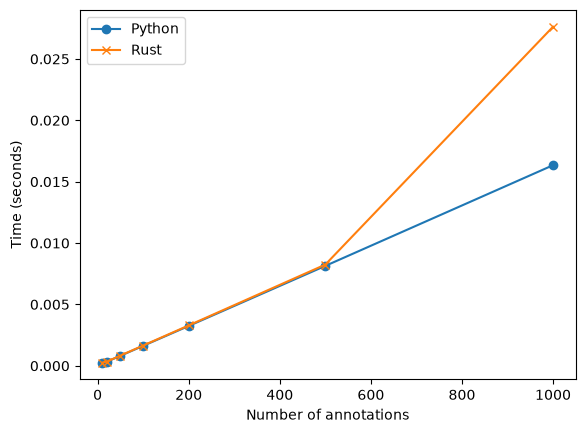

In [6]:
import time

import matplotlib.pyplot as plt
import numpy as np


def make_test_data(
    num_patches: int,
    num_classes: int,
    rng: np.random.Generator,
) -> tuple[
    np.ndarray,
    dict[str, np.ndarray],
    dict[int, str],
    dict[int, list[int]],
]:
    """Generate test data for build single qupath feature."""
    # Example square polygons.
    centres = rng.uniform(0, 10000, size=(num_patches, 2))

    square = np.array(
        [
            [-5.0, -5.0],
            [5.0, -5.0],
            [5.0, 5.0],
            [-5.0, 5.0],
            [-5.0, -5.0],
        ]
    )

    contours = np.array(
        [centre + square for centre in centres],
        dtype=object,
    )

    class_probs = rng.random((num_patches, num_classes))
    class_probs /= class_probs.sum(axis=1, keepdims=True)

    preds = np.argmax(class_probs, axis=1).astype(np.int32)

    processed_predictions = {
        "type": preds,
        "prob": np.max(class_probs, axis=1),
        "centroid": centres,
    }

    class_dict = {index: f"class_{index}" for index in range(num_classes)}

    cmap = plt.colormaps["tab20"].resampled(num_classes)

    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    return (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    )


rng = np.random.default_rng(42)

scale_factor = (0.5, 0.5)
origin = (0.0, 0.0)

sizes = []
timings = []

for num_patches in [10, 20, 50, 100, 200, 500, 1000]:
    num_classes = min(num_patches, 100)

    (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    ) = make_test_data(
        num_patches,
        num_classes,
        rng,
    )

    python_store = PyDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    rust_store = RustDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    python_times = []
    rust_times = []

    for _ in range(10):
        # Python
        start_time = time.time()

        python_objects = [
            python_store.build_single_annotation(
                i,
                class_dict,
                origin,
                scale_factor,
            )
            for i in range(num_patches)
        ]

        python_times.append(time.time() - start_time)

        start_time = time.time()

        rust_objects = [
            rust_store.build_single_annotation(i, class_dict, origin, scale_factor)
            for i in range(num_patches)
        ]

        rust_times.append(time.time() - start_time)

    sizes.append(num_patches)

    timings.append(
        [
            np.mean(python_times),
            np.mean(rust_times),
        ]
    )

timings = np.asarray(timings)

plt.plot(sizes, timings[:, 0], label="Python", marker="o")
plt.plot(sizes, timings[:, 1], label="Rust", marker="x")
plt.xlabel("Number of annotations")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

# Part 3: Compute QuPath Json



### DaskDelayedJSONStore written fully in python



In [7]:
from pathlib import Path

import numpy as np
from dask import delayed
from tqdm.auto import tqdm

from tiatoolbox.annotation.storage import Annotation
from tiatoolbox.utils.misc import save_qupath_json, tqdm_dask_progress_bar


class PyDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def _build_single_qupath_feature(
        self,
        i: int,
        class_dict: dict | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
        class_colors: dict,
    ) -> dict:
        """Build a single feature for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

            class_colors (dict):
                Maps classes to specific colors.

        Returns:
            dict:
                A fully constructed Feature dictionary instance for writing
                to QuPath JSON.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )
        geo_map = mapping(geom)

        props = {}
        class_value = None
        class_name = None

        for key, arr in self._processed_predictions.items():
            value = arr[i].tolist() if hasattr(arr[i], "tolist") else arr[i]

            if key == "type":
                # Handle None class name
                if value is None:
                    # Assign default class 0
                    class_value = 0
                    class_name = class_dict.get(0, 0)
                    props["type"] = class_name
                    continue

                # Safe class lookup
                if class_dict is not None and value in class_dict:
                    class_name = class_dict[value]
                else:
                    # Already a name or no mapping available
                    class_name = value

                props["type"] = class_name
                class_value = value
            else:
                if value is None:
                    continue
                props[key] = np.array(value).tolist()

        # Classification block
        if class_name is not None and class_value in class_colors:
            color = class_colors[class_value]
            props["classification"] = {
                "name": class_name,
                "color": color,
            }
            props["class_value"] = class_value

        return {
            "type": "Feature",
            "id": f"object_{i}",
            "geometry": geo_map,
            "properties": props,
            "objectType": "annotation",
            "name": class_name if class_name is not None else "object",
        }

    def compute_qupath_json(
        self,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float] = (0, 0),
        scale_factor: tuple[float, float] = (1, 1),
        save_path: Path | None = None,
        batch_size: int = 100,
        num_workers: int = 0,
        *,
        verbose: bool = True,
    ) -> Path:
        """Compute annotations in batches and return/save QuPath JSON."""
        num_contours = len(self._contours)
        features: list[dict] = []

        if class_dict is None:
            type_arr = self._processed_predictions.get("type")

            # Extract only valid class IDs/names
            valid_ids = [v for v in type_arr if v is not None]

            if len(valid_ids) == 0:
                # No class info at all → fallback
                class_dict = {0: 0}
            # Numeric class IDs
            elif all(isinstance(v, (int, np.integer)) for v in valid_ids):
                max_class = int(max(valid_ids))
                class_dict = {i: i for i in range(max_class + 1)}
            else:
                # Already class names
                unique_names = sorted(set(valid_ids))
                class_dict = {name: name for name in unique_names}

        # Enumerate class_dict keys to assign stable integer color indices
        class_keys = list(class_dict.keys())
        num_classes = len(class_keys)
        cmap = plt.colormaps["tab20"].resampled(num_classes)

        class_colors = {
            key: [
                int(cmap(i)[0] * 255),
                int(cmap(i)[1] * 255),
                int(cmap(i)[2] * 255),
            ]
            for i, key in enumerate(class_keys)
        }

        # Batch processing (mirrors compute_annotations)
        for batch_id in tqdm(
            range(0, num_contours, batch_size),
            leave=False,
            desc="Calculating QuPath features in batches.",
            disable=not verbose,
        ):
            delayed_tasks = [
                delayed(self._build_single_qupath_feature)(
                    i,
                    class_dict,
                    origin,
                    scale_factor,
                    class_colors,
                )
                for i in tqdm(
                    range(batch_id, min(batch_id + batch_size, num_contours)),
                    leave=False,
                    desc="Creating delayed tasks for QuPath JSON",
                    disable=not verbose,
                )
            ]

            # Compute batch immediately
            batch_features = tqdm_dask_progress_bar(
                write_tasks=delayed_tasks,
                desc="Computing QuPath features",
                verbose=verbose,
                num_workers=num_workers,
            )
            features.extend(batch_features)

        qupath_json = {"type": "FeatureCollection", "features": features}

        if save_path is not None:
            save_qupath_json(
                save_path=save_path,
                qupath_json=qupath_json,
            )

        return qupath_json

### RustDaskDelayedJSONStore with some code written in rust



In [8]:
class RustDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def _build_single_qupath_feature(
        self,
        i: int,
        class_dict: dict | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
        class_colors: dict,
    ) -> dict:
        """Build a single feature for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

            class_colors (dict):
                Maps classes to specific colors.

        Returns:
            dict:
                A fully constructed Feature dictionary instance for writing
                to QuPath JSON.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )
        geo_map = mapping(geom)

        props = {}
        class_value = None
        class_name = None

        for key, arr in self._processed_predictions.items():
            value = arr[i].tolist() if hasattr(arr[i], "tolist") else arr[i]

            if key == "type":
                # Handle None class name
                if value is None:
                    # Assign default class 0
                    class_value = 0
                    class_name = class_dict.get(0, 0)
                    props["type"] = class_name
                    continue

                # Safe class lookup
                if class_dict is not None and value in class_dict:
                    class_name = class_dict[value]
                else:
                    # Already a name or no mapping available
                    class_name = value

                props["type"] = class_name
                class_value = value
            else:
                if value is None:
                    continue
                props[key] = np.array(value).tolist()

        # Classification block
        if class_name is not None and class_value in class_colors:
            color = class_colors[class_value]
            props["classification"] = {
                "name": class_name,
                "color": color,
            }
            props["class_value"] = class_value

        return {
            "type": "Feature",
            "id": f"object_{i}",
            "geometry": geo_map,
            "properties": props,
            "objectType": "annotation",
            "name": class_name if class_name is not None else "object",
        }

    def compute_qupath_json(
        self,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float] = (0, 0),
        scale_factor: tuple[float, float] = (1, 1),
        save_path: Path | None = None,
        batch_size: int = 100,
        num_workers: int = 0,
        *,
        verbose: bool = True,
    ) -> Path:
        """Compute annotations in batches and return/save QuPath JSON."""
        if class_dict is None:
            class_dict = {}
        features = rmultitask.compute_qupath_json(
            class_dict,
            origin,
            scale_factor,
            batch_size,
            verbose,
            num_workers,
            len(self._contours),
            self._processed_predictions.get("type").tolist(),
            plt,
            self._build_single_qupath_feature,
            delayed,
            tqdm_dask_progress_bar,
        )

        qupath_json = {"type": "FeatureCollection", "features": features}

        if save_path is not None:
            save_qupath_json(
                save_path=save_path,
                qupath_json=qupath_json,
            )

        return qupath_json

## Comparison of speed it takes to run code in rust vs python



In [9]:
import time

import matplotlib.pyplot as plt
import numpy as np


def make_test_data(
    num_patches: int,
    num_classes: int,
    rng: np.random.Generator,
) -> tuple[
    np.ndarray,
    dict[str, np.ndarray],
    dict[int, str],
    dict[int, list[int]],
]:
    """Generate test data for build single qupath feature."""
    # Example square polygons.
    centres = rng.uniform(0, 10000, size=(num_patches, 2))

    square = np.array(
        [
            [-5.0, -5.0],
            [5.0, -5.0],
            [5.0, 5.0],
            [-5.0, 5.0],
            [-5.0, -5.0],
        ]
    )

    contours = np.array(
        [centre + square for centre in centres],
        dtype=object,
    )

    class_probs = rng.random((num_patches, num_classes))
    class_probs /= class_probs.sum(axis=1, keepdims=True)

    preds = np.argmax(class_probs, axis=1).astype(np.int32)

    processed_predictions = {
        "type": preds,
        "prob": np.max(class_probs, axis=1),
        "centroid": centres,
    }

    class_dict = {index: f"class_{index}" for index in range(num_classes)}

    cmap = plt.colormaps["tab20"].resampled(num_classes)

    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    return (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    )


rng = np.random.default_rng(42)

scale_factor = (0.5, 0.5)
origin = (0.0, 0.0)

sizes = []
timings = []

for num_patches in [10, 20, 50, 100, 200, 500, 1000]:
    num_classes = min(num_patches, 100)

    (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    ) = make_test_data(
        num_patches,
        num_classes,
        rng,
    )

    python_store = PyDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    rust_store = RustDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    python_times = []
    rust_times = []

    for _ in range(10):
        # Python
        start_time = time.time()

        python_objects = python_store.compute_qupath_json(
            class_dict, (0, 0), (1, 1), None, 100, 1, verbose=False
        )

        python_times.append(time.time() - start_time)

        start_time = time.time()

        rust_objects = rust_store.compute_qupath_json(
            class_dict, (0, 0), (1, 1), None, 100, 1, verbose=False
        )

        rust_times.append(time.time() - start_time)

    sizes.append(num_patches)

    timings.append(
        [
            np.mean(python_times),
            np.mean(rust_times),
        ]
    )

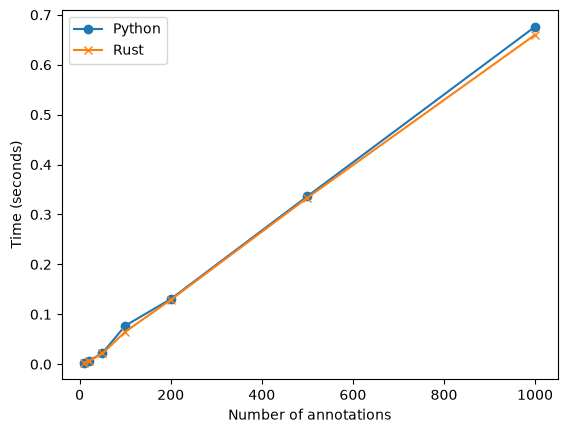

In [10]:
timings = np.asarray(timings)

plt.plot(sizes, timings[:, 0], label="Python", marker="o")
plt.plot(sizes, timings[:, 1], label="Rust", marker="x")
plt.xlabel("Number of annotations")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()

# Part 4: Compute Annotations



### DaskDelayedJSONStore written fully in python



In [11]:
import numpy as np

from tiatoolbox.annotation import SQLiteStore
from tiatoolbox.annotation.storage import Annotation


class PyDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def _build_single_annotation(
        self,
        i: int,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
    ) -> Annotation:
        """Build a single annotation for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

        Returns:
            Annotation:
                A fully constructed TIAToolbox `Annotation` instance.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )

        properties = {
            prop: (
                class_dict[self._processed_predictions[prop][i]]
                if prop == "type" and class_dict is not None
                else np.array(self._processed_predictions[prop][i]).tolist()
            )
            for prop in self._processed_predictions
        }

        return Annotation(geom, properties)

    def compute_annotations(
        self,
        store: SQLiteStore,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float] = (0, 0),
        scale_factor: tuple[float, float] = (1, 1),
        batch_size: int = 100,
        num_workers: int = 0,
        *,
        verbose: bool = True,
    ) -> SQLiteStore:
        """Compute annotations in batches and write them to a SQLiteStore.

        This method creates Dask Delayed tasks in batches to reduce scheduler
        overhead. Each batch is computed and written immediately using
        ``store.append_many()``.

        Args:
            store (SQLiteStore):
                A TIAToolbox SQLiteStore instance used to write annotations.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.

            origin (tuple[float, float], optional):
                Translation offset ``(x, y)`` applied after scaling.
                Defaults to ``(0, 0)``.

            scale_factor (tuple[float, float], optional):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.
                Defaults to ``(1, 1)``.

            batch_size (int, optional):
                Number of annotations to compute per batch. Larger batches
                reduce Dask scheduler overhead. Defaults to ``100``.

            num_workers (int, optional):
                Number of Dask workers to use. ``0`` means auto-detect.
                Passed through to the progress bar helper. Defaults to ``0``.

            verbose (bool, optional):
                Whether to display progress bars. Defaults to ``True``.

        Returns:
            SQLiteStore:
                The same store instance, after all annotations have been written.

        """
        num_contours = len(self._contours)
        for batch_id in tqdm(
            range(0, num_contours, batch_size),
            leave=False,
            desc="Calculating annotations in batches.",
            disable=not verbose,
        ):
            delayed_tasks = [
                delayed(self._build_single_annotation)(
                    i,
                    class_dict,
                    origin,
                    scale_factor,
                )
                for i in tqdm(
                    range(batch_id, min(batch_id + batch_size, num_contours)),
                    leave=False,
                    desc="Creating list of delayed tasks for writing annotations",
                    disable=not verbose,
                )
            ]

            store.append_many(
                tqdm_dask_progress_bar(
                    write_tasks=delayed_tasks,
                    desc="Saving annotations",
                    verbose=verbose,
                    num_workers=num_workers,
                )
            )
        return store

### RustDaskDelayedJSONStore with some code written in rust



In [12]:
class RustDaskDelayedJSONStore:
    """Compute and write TIAToolbox annotations using batched Dask Delayed tasks.

    This class parallelizes annotation construction using Dask Delayed while
    avoiding serialization overhead by storing contours and prediction arrays
    as instance attributes. Annotations are computed in batches and written
    directly to a TIAToolbox `SQLiteStore` via `append_many()`.

    """

    def __init__(
        self,
        contours: np.ndarray,
        processed_predictions: dict,
    ) -> None:
        """Initialize :class:`DaskDelayedAnnotationStore`.

        Args:
            contours (np.ndarray):
                A sequence of polygon contours. Each element is an array-like
                of shape ``(N_i, 2)`` representing the coordinates of a single
                object contour.

            processed_predictions (dict):
                A dictionary of per-object prediction fields. Each key maps to
                an array-like of length ``len(contours)``. Example keys include
                ``"type"``, ``"prob"``, ``"centroid"``, etc. May also contain
                a global field ``"geom_type"``.

        """
        self._contours = contours
        self._processed_predictions = processed_predictions

    def _build_single_annotation(
        self,
        i: int,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float],
        scale_factor: tuple[float, float],
    ) -> Annotation:
        """Build a single annotation for index ``i``.

        This method performs:
        - geometry creation
        - coordinate scaling and translation
        - per-object property extraction
        - optional class label mapping

        Args:
            i (int):
                Index of the object to convert into an annotation.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.
                If ``None``, raw integer class IDs are used.

            origin (tuple[float, float]):
                Translation offset ``(x, y)`` applied after scaling.

            scale_factor (tuple[float, float]):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.

        Returns:
            Annotation:
                A fully constructed TIAToolbox `Annotation` instance.

        """
        geom = make_valid_poly(
            feature2geometry(
                {
                    "type": self._processed_predictions.get("geom_type", "Polygon"),
                    "coordinates": scale_factor * np.array([self._contours[i]]),
                }
            ),
            tuple(origin),
        )

        properties = {
            prop: (
                class_dict[self._processed_predictions[prop][i]]
                if prop == "type" and class_dict is not None
                else np.array(self._processed_predictions[prop][i]).tolist()
            )
            for prop in self._processed_predictions
        }

        return Annotation(geom, properties)

    def compute_annotations(
        self,
        store: SQLiteStore,
        class_dict: dict[int, str] | None,
        origin: tuple[float, float] = (0, 0),
        scale_factor: tuple[float, float] = (1, 1),
        batch_size: int = 100,
        num_workers: int = 0,
        *,
        verbose: bool = True,
    ) -> SQLiteStore:
        """Compute annotations in batches and write them to a SQLiteStore.

        This method creates Dask Delayed tasks in batches to reduce scheduler
        overhead. Each batch is computed and written immediately using
        ``store.append_many()``.

        Args:
            store (SQLiteStore):
                A TIAToolbox SQLiteStore instance used to write annotations.

            class_dict (dict[int, str] | None):
                Optional mapping from integer class IDs to string labels.

            origin (tuple[float, float], optional):
                Translation offset ``(x, y)`` applied after scaling.
                Defaults to ``(0, 0)``.

            scale_factor (tuple[float, float], optional):
                Scaling factors ``(sx, sy)`` applied to contour coordinates.
                Defaults to ``(1, 1)``.

            batch_size (int, optional):
                Number of annotations to compute per batch. Larger batches
                reduce Dask scheduler overhead. Defaults to ``100``.

            num_workers (int, optional):
                Number of Dask workers to use. ``0`` means auto-detect.
                Passed through to the progress bar helper. Defaults to ``0``.

            verbose (bool, optional):
                Whether to display progress bars. Defaults to ``True``.

        Returns:
            SQLiteStore:
                The same store instance, after all annotations have been written.

        """
        return rmultitask.compute_annotations(
            store,
            class_dict,
            origin,
            scale_factor,
            batch_size,
            num_workers,
            verbose,
            len(self._contours),
            self._build_single_annotation,
            delayed,
            tqdm_dask_progress_bar,
        )

## Comparison of speed it takes to run code in rust vs python



In [13]:
import time

import matplotlib.pyplot as plt
import numpy as np


def make_test_data(
    num_patches: int,
    num_classes: int,
    rng: np.random.Generator,
) -> tuple[
    np.ndarray,
    dict[str, np.ndarray],
    dict[int, str],
    dict[int, list[int]],
]:
    """Generate test data for build single qupath feature."""
    # Example square polygons.
    centres = rng.uniform(0, 10000, size=(num_patches, 2))

    square = np.array(
        [
            [-5.0, -5.0],
            [5.0, -5.0],
            [5.0, 5.0],
            [-5.0, 5.0],
            [-5.0, -5.0],
        ]
    )

    contours = np.array(
        [centre + square for centre in centres],
        dtype=object,
    )

    class_probs = rng.random((num_patches, num_classes))
    class_probs /= class_probs.sum(axis=1, keepdims=True)

    preds = np.argmax(class_probs, axis=1).astype(np.int32)

    processed_predictions = {
        "type": preds,
        "prob": np.max(class_probs, axis=1),
        "centroid": centres,
    }

    class_dict = {index: f"class_{index}" for index in range(num_classes)}

    cmap = plt.colormaps["tab20"].resampled(num_classes)

    class_colours = {
        class_idx: [
            int(cmap(class_idx)[0] * 255),
            int(cmap(class_idx)[1] * 255),
            int(cmap(class_idx)[2] * 255),
        ]
        for class_idx in class_dict
    }

    return (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    )


rng = np.random.default_rng(42)

scale_factor = (0.5, 0.5)
origin = (0.0, 0.0)

sizes = []
timings = []

for num_patches in [10, 20, 50, 100, 200, 500, 1000]:
    num_classes = min(num_patches, 100)

    (
        contours,
        processed_predictions,
        class_dict,
        class_colours,
    ) = make_test_data(
        num_patches,
        num_classes,
        rng,
    )

    python_store = PyDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    rust_store = RustDaskDelayedJSONStore(
        contours,
        processed_predictions,
    )

    python_times = []
    rust_times = []

    for _ in range(10):
        # Python
        store = SQLiteStore()
        start_time = time.time()

        python_objects = python_store.compute_annotations(
            store, class_dict, (0, 0), (1, 1), 100, 1, verbose=False
        )

        python_times.append(time.time() - start_time)
        store = SQLiteStore()
        start_time = time.time()

        rust_objects = rust_store.compute_annotations(
            store, class_dict, (0, 0), (1, 1), 100, 1, verbose=False
        )

        rust_times.append(time.time() - start_time)

    sizes.append(num_patches)

    timings.append(
        [
            np.mean(python_times),
            np.mean(rust_times),
        ]
    )

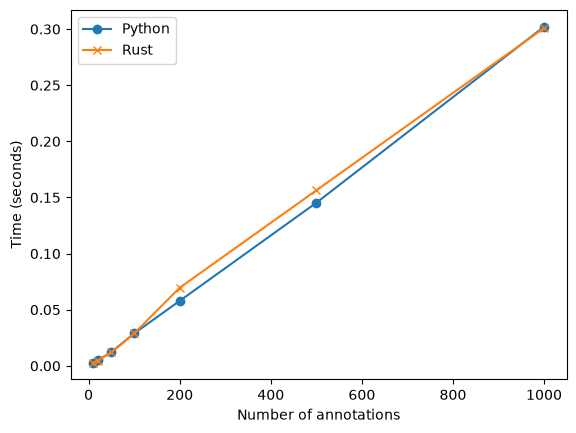

In [14]:
timings = np.asarray(timings)

plt.plot(sizes, timings[:, 0], label="Python", marker="o")
plt.plot(sizes, timings[:, 1], label="Rust", marker="x")
plt.xlabel("Number of annotations")
plt.ylabel("Time (seconds)")
plt.legend()
plt.show()